In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==========================================
# Load Clean Dataset
# ==========================================

df = pd.read_csv("/content/clean_salary_dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
target = "salary"

In [4]:
X = df.drop(columns=[target])

y = df[target]

In [5]:
print(X.head())

print(y.head())

            job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             Phd             4   
3    Business Analyst                19             Phd            13   
4     Product Manager                15        Bachelor             7   

        industry company_size   location remote_work  certifications  \
0     Healthcare       Medium      India      Hybrid               2   
1        Telecom        Small  Australia          No               0   
2          Media       Medium  Singapore          No               1   
3         Retail       Medium     Canada         Yes               0   
4  Manufacturing        Large     Sweden         Yes               0   

   salary_sar  
0   411392.88  
1   352552.64  
2   556942.48  
3   711102.48  
4   620659.44  
0    109413.0
1     93764.0
2   

In [6]:
numerical_columns = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

print(numerical_columns)

['experience_years', 'skills_count', 'certifications', 'salary_sar']


In [7]:
categorical_columns = X.select_dtypes(
    include="object"
).columns.tolist()

print(categorical_columns)

['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']


In [8]:
print("Categorical Features")

print(categorical_columns)

print()

print("Numerical Features")

print(numerical_columns)

Categorical Features
['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']

Numerical Features
['experience_years', 'skills_count', 'certifications', 'salary_sar']


In [9]:
encoder = OneHotEncoder(
    handle_unknown="ignore"
)

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            encoder,
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [11]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [12]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(200000, 10)
(50000, 10)
(200000,)
(50000,)


In [13]:
preprocessor.fit(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['job_title', 'education_level', 'industry',
                                  'company_size', 'location', 'remote_work'])])

In [14]:
X_train_processed = preprocessor.transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [15]:
print(X_train_processed.shape)

print(X_test_processed.shape)

(200000, 49)
(50000, 49)


In [16]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['categorical__job_title_AI Engineer'
 'categorical__job_title_Backend Developer'
 'categorical__job_title_Business Analyst'
 'categorical__job_title_Cloud Engineer'
 'categorical__job_title_Cybersecurity Analyst'
 'categorical__job_title_Data Analyst'
 'categorical__job_title_Data Scientist'
 'categorical__job_title_DevOps Engineer'
 'categorical__job_title_Frontend Developer'
 'categorical__job_title_Machine Learning Engineer'
 'categorical__job_title_Product Manager'
 'categorical__job_title_Software Engineer'
 'categorical__education_level_Bachelor'
 'categorical__education_level_Diploma'
 'categorical__education_level_High School'
 'categorical__education_level_Master' 'categorical__education_level_Phd'
 'categorical__industry_Consulting' 'categorical__industry_Education'
 'categorical__industry_Finance' 'categorical__industry_Government'
 'categorical__industry_Healthcare' 'categorical__industry_Manufacturing'
 'categorical__industry_Media' 'categorical__industry_Retail'
 'catego

In [17]:
joblib.dump(
    preprocessor,
    "salary_preprocessor.pkl"
)

['salary_preprocessor.pkl']

In [18]:
import os

os.listdir()

['.config',
 'salary_preprocessor.pkl',
 'clean_salary_dataset.csv',
 'sample_data']

In [19]:
preprocessor = joblib.load(
    "salary_preprocessor.pkl"
)

In [20]:
sample = X.iloc[[0]]

sample

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary_sar
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,411392.88


In [21]:
processed = preprocessor.transform(sample)

processed.shape

(1, 49)

In [22]:
print("Original Features")

print(X.shape[1])

print()

print("Processed Features")

print(X_train_processed.shape[1])

Original Features
10

Processed Features
49


In [23]:
print(y.describe())

count    250000.000000
mean     145718.080524
std       37407.952729
min       31867.000000
25%      119358.000000
50%      143453.000000
75%      169492.000000
max      333046.000000
Name: salary, dtype: float64


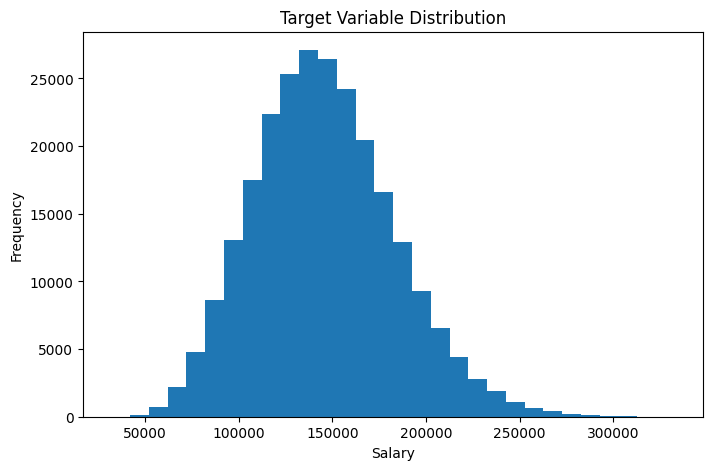

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(y,bins=30)

plt.title("Target Variable Distribution")

plt.xlabel("Salary")

plt.ylabel("Frequency")

plt.show()

In [25]:
joblib.dump(X_train,"X_train.pkl")
joblib.dump(X_test,"X_test.pkl")

joblib.dump(y_train,"y_train.pkl")
joblib.dump(y_test,"y_test.pkl")

['y_test.pkl']

Loaded the cleaned dataset.
Separated features (X) and target (y).
Identified numerical and categorical columns.
Applied One-Hot Encoding to categorical features.
Split the data into training and testing sets.
Created a reusable preprocessing pipeline.
Saved the preprocessor and datasets for future notebooks.